Phase: Baseline Multiclass Models + Recall-Focused Evaluation + Feature Importance/Selection
Goal: Train baseline multiclass models for next-3h risk class, evaluate with recall focus, tune High-risk threshold τ, then perform feature selection using permutation importance (Option A: original features).

Input: processed_data/supervised_hood_3h_multiclass.csv
Outputs: saved models + selected feature list + chosen τ for Streamlit.

In [2]:

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix, classification_report,
    recall_score, precision_score
)

import matplotlib.pyplot as plt
import joblib

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data" / "processed"
SUPERVISED_PATH = DATA_DIR / "supervised_hood_3h_multiclass.csv"

In [3]:
# --- Load supervised dataset ---
df = pd.read_csv(SUPERVISED_PATH, low_memory=False)
df["time_3h"] = pd.to_datetime(df["time_3h"], errors="coerce")
df["HOOD_158_CODE"] = df["HOOD_158_CODE"].astype(str).str.zfill(3)
df["y_class"] = pd.to_numeric(df["y_class"], errors="coerce").astype("int8")
df = df.sort_values(["time_3h","HOOD_158_CODE"]).reset_index(drop=True)

print("Shape:", df.shape)
print("Class distribution:")
print(df["y_class"].value_counts(normalize=True).sort_index().round(4))

Shape: (1383922, 50)
Class distribution:
y_class
0    0.8930
1    0.0927
2    0.0143
Name: proportion, dtype: float64


In [4]:
# --- Time-based split ---
t = df["time_3h"]
train_end = pd.Timestamp("2024-12-31 23:59:59")
val_end   = pd.Timestamp("2025-06-30 23:59:59")

train_mask = t <= train_end
val_mask   = (t > train_end) & (t <= val_end)
test_mask  = t > val_end

y = df["y_class"].copy()
X = df.drop(columns=[c for c in ["y_class","y_count_next"] if c in df.columns], errors="ignore").copy()

# Do not use raw timestamp as feature (we already have time features)
X = X.drop(columns=["time_3h"], errors="ignore")

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_val, y_val     = X.loc[val_mask], y.loc[val_mask]
X_test, y_test   = X.loc[test_mask], y.loc[test_mask]

print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (922720, 47) (228784, 47) (232418, 47)


In [5]:
# --- Identify categorical and numeric columns ---
cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
if "HOOD_158_CODE" in X_train.columns and "HOOD_158_CODE" not in cat_cols:
    cat_cols.append("HOOD_158_CODE")

num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Numeric:", len(num_cols), "Categorical:", len(cat_cols), cat_cols)

Numeric: 46 Categorical: 1 ['HOOD_158_CODE']


In [6]:

# --- Preprocess: impute + scale numeric, one-hot categorical ---
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

In [7]:
# --- Helpers for evaluation ---
def plot_confusion(cm, labels=(0,1,2), title="Confusion Matrix"):
    fig, ax = plt.subplots()
    ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    plt.show()

def eval_multiclass(y_true, y_pred, name="Model"):
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    rec = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    rec_high = recall_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    prec_high = precision_score((y_true==2).astype(int), (y_pred==2).astype(int), zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n=== {name} ===")
    print("Per-class recall [0,1,2]:", np.round(rec, 4))
    print("Macro recall:", round(float(macro_rec), 4))
    print("High-risk recall:", round(float(rec_high), 4))
    print("High-risk precision:", round(float(prec_high), 4))
    print("\n", classification_report(y_true, y_pred, digits=4, zero_division=0))
    plot_confusion(cm, title=f"{name} Confusion Matrix")
     


=== Dummy (Most Frequent) - Val ===
Per-class recall [0,1,2]: [1. 0. 0.]
Macro recall: 0.3333
High-risk recall: 0.0
High-risk precision: 0.0

               precision    recall  f1-score   support

           0     0.8951    1.0000    0.9447    204791
           1     0.0000    0.0000    0.0000     20758
           2     0.0000    0.0000    0.0000      3235

    accuracy                         0.8951    228784
   macro avg     0.2984    0.3333    0.3149    228784
weighted avg     0.8013    0.8951    0.8456    228784



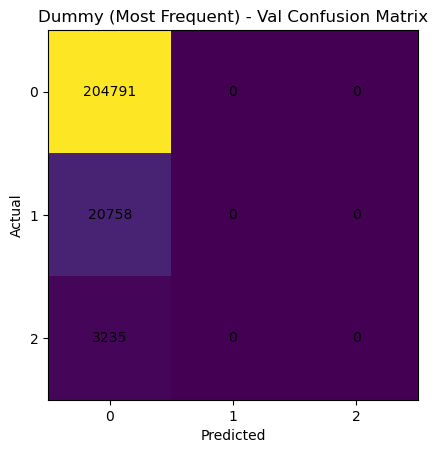

In [8]:
# --- Baseline 1: Dummy (most frequent) ---
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
pred_val = dummy.predict(X_val)
eval_multiclass(y_val, pred_val, name="Dummy (Most Frequent) - Val")


=== LogReg Argmax - Val ===
Per-class recall [0,1,2]: [0.6547 0.3466 0.6065]
Macro recall: 0.5359
High-risk recall: 0.6065
High-risk precision: 0.06

               precision    recall  f1-score   support

           0     0.9519    0.6547    0.7758    204791
           1     0.1303    0.3466    0.1894     20758
           2     0.0600    0.6065    0.1092      3235

    accuracy                         0.6261    228784
   macro avg     0.3807    0.5359    0.3581    228784
weighted avg     0.8648    0.6261    0.7132    228784



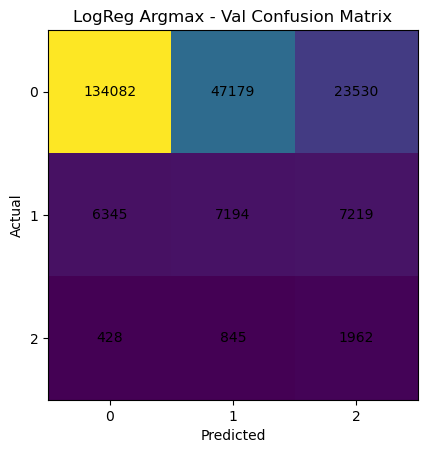


=== LogReg Argmax - Test ===
Per-class recall [0,1,2]: [0.6379 0.3326 0.6725]
Macro recall: 0.5477
High-risk recall: 0.6725
High-risk precision: 0.0615

               precision    recall  f1-score   support

           0     0.9543    0.6379    0.7646    207818
           1     0.1253    0.3326    0.1820     21189
           2     0.0615    0.6725    0.1127      3411

    accuracy                         0.6105    232418
   macro avg     0.3804    0.5477    0.3531    232418
weighted avg     0.8657    0.6105    0.7020    232418



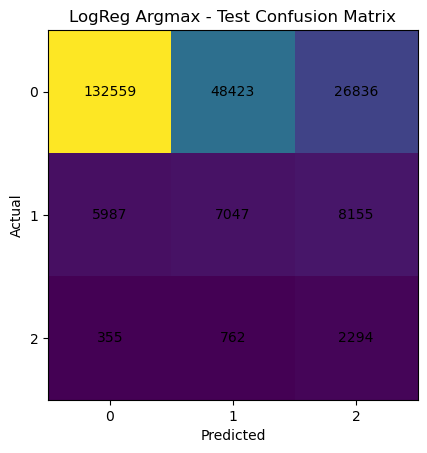

In [9]:
# --- Baseline 2: Logistic Regression (convergence fix) ---
logreg = LogisticRegression(
    solver="saga",
    max_iter=2000,   # fix convergence
    tol=1e-3,
    n_jobs=-1,
    class_weight="balanced"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

logreg_pipe.fit(X_train, y_train)

pred_val = logreg_pipe.predict(X_val)
eval_multiclass(y_val, pred_val, name="LogReg Argmax - Val")

pred_test = logreg_pipe.predict(X_test)
eval_multiclass(y_test, pred_test, name="LogReg Argmax - Test")